<a href="https://colab.research.google.com/github/Hangyeol82/Computer_Vision/blob/main/A_%E1%84%89%E1%85%B5%E1%86%AF%E1%84%92%E1%85%A5%E1%86%B7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [실험 A] 손실 함수 비교 : CrossEntropy Loss vs MSE Loss (with softmax)

In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

In [3]:
# ============================================================
# 1. Seed 고정
# ============================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42) # 실험 결과 동일성을 위하여 seed 고정

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
# ============================================================
# 2. Digits Dataset 불러오기
# ============================================================

def load_digits_dataset(batch_size=64):
    digits = load_digits()

    X = digits.data.astype(np.float32)
    y = digits.target.astype(np.int64)

    # 입력값 정규화를 통해 안정적인 학습 유도
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,    # 학습 데이터와 테스트 데이터를 8:2 비율로 분리
        random_state=42,
        stratify=y
    )

    X_train = torch.tensor(X_train, dtype=torch.float32)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    y_test = torch.tensor(y_test, dtype=torch.long)

    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, test_loader, 64, 10


train_loader, test_loader, input_size, num_classes = load_digits_dataset()

In [5]:
# ============================================================
# 3. MLP 모델 정의
# 구조: 64 → 256 → 128 → 10
# ============================================================

class MLP(nn.Module):
    def __init__(self, input_size=64, num_classes=10):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 256), # 64차원 입력을 256차원 특징으로 변환
            nn.ReLU(),                  # ReLU로 비선형
            nn.Linear(256, 128),        # 256차원을 128차원으로 변환
            nn.ReLU(),
            nn.Linear(128, num_classes) # 10개 숫자에 대한 logits출력
        )

    def forward(self, x):
        return self.model(x)

In [6]:
# ============================================================
# 4. 평가 함수
# model.eval()과 torch.no_grad() 사용
# ============================================================

def evaluate_model(model, test_loader, loss_type):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            if loss_type == "cross_entropy":
                loss_fn = nn.CrossEntropyLoss()
                loss = loss_fn(outputs, labels)

            elif loss_type == "mse":
                loss_fn = nn.MSELoss()

                # MSE는 softmax 확률값과 one-hot label을 비교
                probs = torch.softmax(outputs, dim=1)
                one_hot_labels = F.one_hot(
                    labels,
                    num_classes=outputs.shape[1]
                ).float()

                loss = loss_fn(probs, one_hot_labels)

            preds = torch.argmax(outputs, dim=1)

            total_loss += loss.item()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(test_loader)
    accuracy = correct / total

    return avg_loss, accuracy

In [7]:
# ============================================================
# 5. 학습 함수
# ============================================================

def train_model(model, train_loader, test_loader, loss_type, epochs=50):
    model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    history = {
        "train_loss": [],
        "test_loss": [],
        "train_acc": [],
        "test_acc": [],
        "grad_norms": []
    }

    for epoch in range(epochs):
        model.train()

        total_loss = 0.0
        correct = 0
        total = 0
        epoch_grad_norms = []

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)

            if loss_type == "cross_entropy":
                # softmax를 내부에 갖고있음
                loss_fn = nn.CrossEntropyLoss()
                loss = loss_fn(outputs, labels)

            elif loss_type == "mse":
                loss_fn = nn.MSELoss()

                # MSE Loss 사용 시 softmax를 명시적으로 적용
                probs = torch.softmax(outputs, dim=1)

                # label을 one-hot vector로 변환
                one_hot_labels = F.one_hot(
                    labels,
                    num_classes=outputs.shape[1]
                ).float()

                loss = loss_fn(probs, one_hot_labels)

            loss.backward() # 역전파를 통해 gradient 계산

            # Gradient 차이를 확인하기 위해 gradient norm 저장
            grad_norm = 0.0
            for param in model.parameters():
                if param.grad is not None:
                    grad_norm += param.grad.norm().item()

            epoch_grad_norms.append(grad_norm)

            optimizer.step()

            preds = torch.argmax(outputs, dim=1)
            # loss와 accuracy 계산을 위한 결과 누적
            total_loss += loss.item()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc = correct / total

        test_loss, test_acc = evaluate_model(
            model,
            test_loader,
            loss_type
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["grad_norms"].append(np.mean(epoch_grad_norms))

        if epoch == 0 or (epoch + 1) % 10 == 0:
            print(
                f"Epoch [{epoch+1:03d}/{epochs}] "
                f"Train Loss: {train_loss:.4f} | "
                f"Train Acc: {train_acc:.4f} | "
                f"Test Loss: {test_loss:.4f} | "
                f"Test Acc: {test_acc:.4f}"
            )

    return history

In [8]:
# ============================================================
# 6. CrossEntropy Loss 실험
# ============================================================

print("========== CrossEntropy Loss 실험 시작 ==========")

set_seed(42) # 동일 학습

model_ce = MLP(
    input_size=input_size,
    num_classes=num_classes
)

history_ce = train_model(
    model=model_ce,
    train_loader=train_loader,
    test_loader=test_loader,
    loss_type="cross_entropy", # cross entropy 사용
    epochs=50
)

========== CrossEntropy Loss 실험 시작 ==========
Epoch [001/50] Train Loss: 1.7341 | Train Acc: 0.6500 | Test Loss: 1.0525 | Test Acc: 0.8000
Epoch [010/50] Train Loss: 0.0169 | Train Acc: 0.9986 | Test Loss: 0.0955 | Test Acc: 0.9694
Epoch [020/50] Train Loss: 0.0032 | Train Acc: 1.0000 | Test Loss: 0.0919 | Test Acc: 0.9722
Epoch [030/50] Train Loss: 0.0013 | Train Acc: 1.0000 | Test Loss: 0.0936 | Test Acc: 0.9750
Epoch [040/50] Train Loss: 0.0007 | Train Acc: 1.0000 | Test Loss: 0.0955 | Test Acc: 0.9722
Epoch [050/50] Train Loss: 0.0004 | Train Acc: 1.0000 | Test Loss: 0.0978 | Test Acc: 0.9750


In [9]:
# ============================================================
# 7. MSE Loss with Softmax 실험
# ============================================================

print("========== MSE Loss with Softmax 실험 시작 ==========")

set_seed(42) # 동일 학습

model_mse = MLP(
    input_size=input_size,
    num_classes=num_classes
)

history_mse = train_model(
    model=model_mse,
    train_loader=train_loader,
    test_loader=test_loader,
    loss_type="mse", # mse 사용
    epochs=50
)

========== MSE Loss with Softmax 실험 시작 ==========
Epoch [001/50] Train Loss: 0.0716 | Train Acc: 0.6054 | Test Loss: 0.0443 | Test Acc: 0.7389
Epoch [010/50] Train Loss: 0.0006 | Train Acc: 0.9979 | Test Loss: 0.0036 | Test Acc: 0.9750
Epoch [020/50] Train Loss: 0.0001 | Train Acc: 1.0000 | Test Loss: 0.0036 | Test Acc: 0.9750
Epoch [030/50] Train Loss: 0.0000 | Train Acc: 1.0000 | Test Loss: 0.0035 | Test Acc: 0.9750
Epoch [040/50] Train Loss: 0.0000 | Train Acc: 1.0000 | Test Loss: 0.0035 | Test Acc: 0.9722
Epoch [050/50] Train Loss: 0.0000 | Train Acc: 1.0000 | Test Loss: 0.0035 | Test Acc: 0.9722


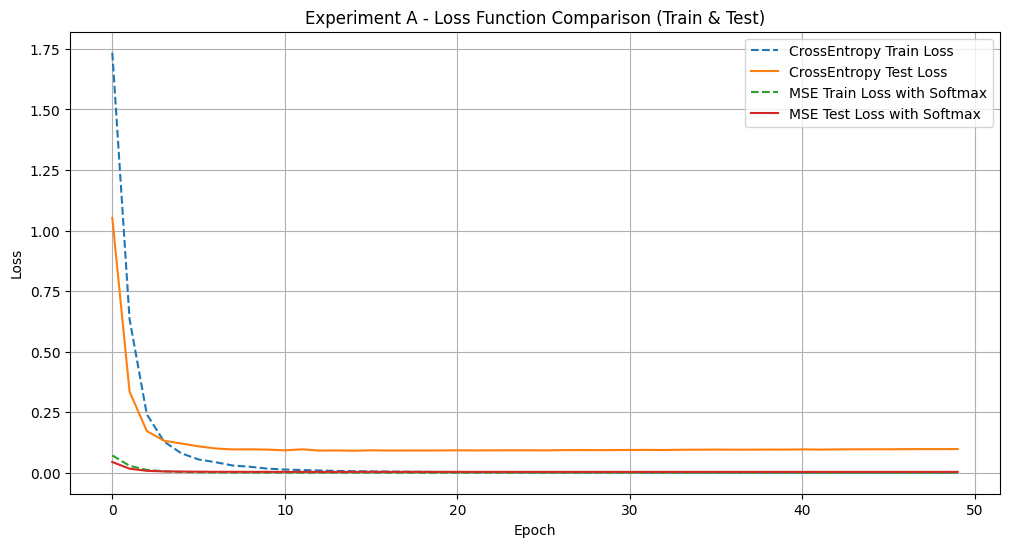

In [10]:
import matplotlib.pyplot as plt

# ============================================================
# 8. Loss 그래프 비교
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(history_ce["train_loss"], label="CrossEntropy Train Loss", linestyle='--')
plt.plot(history_ce["test_loss"], label="CrossEntropy Test Loss")
plt.plot(history_mse["train_loss"], label="MSE Train Loss with Softmax", linestyle='--')
plt.plot(history_mse["test_loss"], label="MSE Test Loss with Softmax")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment A - Loss Function Comparison (Train & Test)")
plt.legend()
plt.grid(True)
plt.show()

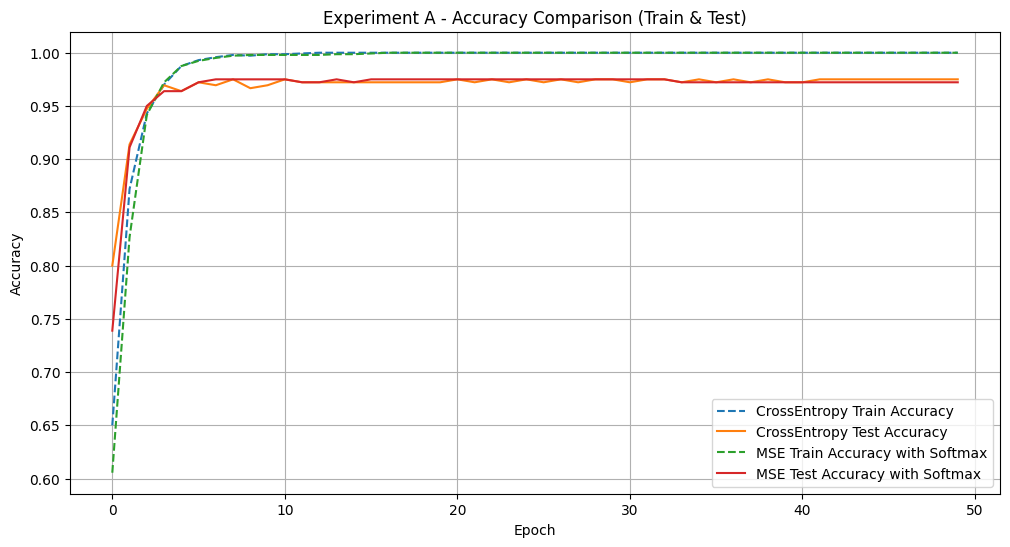

In [14]:
import matplotlib.pyplot as plt

# ============================================================
# 9. Accuracy 그래프 비교
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(history_ce["train_acc"], label="CrossEntropy Train Accuracy", linestyle='--')
plt.plot(history_ce["test_acc"], label="CrossEntropy Test Accuracy")
plt.plot(history_mse["train_acc"], label="MSE Train Accuracy with Softmax", linestyle='--')
plt.plot(history_mse["test_acc"], label="MSE Test Accuracy with Softmax")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Experiment A - Accuracy Comparison (Train & Test)")
plt.legend()
plt.grid(True)
plt.show()

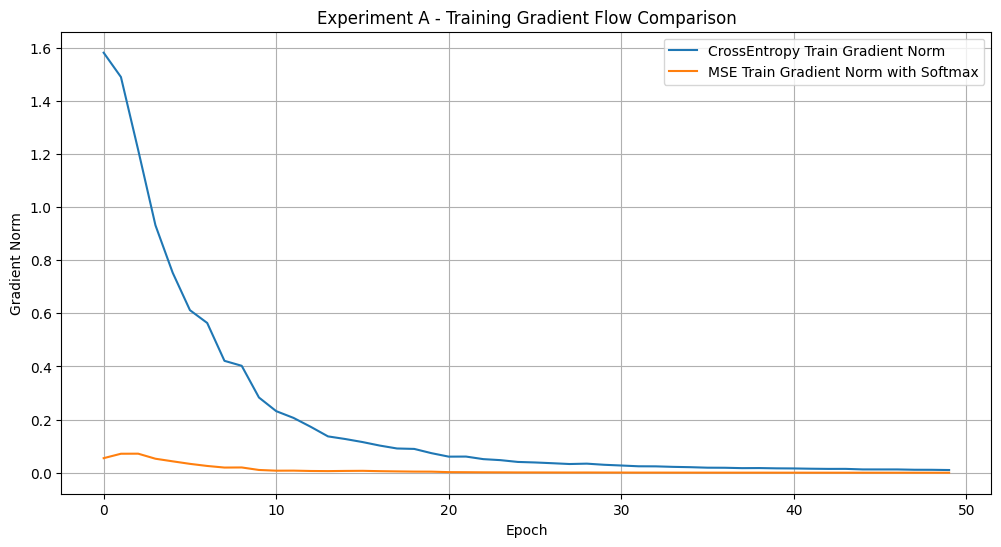

In [15]:
import matplotlib.pyplot as plt

# ============================================================
# 10. Gradient Norm 그래프 비교
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(history_ce["grad_norms"], label="CrossEntropy Train Gradient Norm")
plt.plot(history_mse["grad_norms"], label="MSE Train Gradient Norm with Softmax")

plt.xlabel("Epoch")
plt.ylabel("Gradient Norm")
plt.title("Experiment A - Training Gradient Flow Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
import pandas as pd

# ============================================================
# 11. 정량 비교 표 생성
# ============================================================

def get_convergence_epoch(acc_list):
    final_acc = acc_list[-1]
    target_acc = final_acc * 0.95

    for i, acc in enumerate(acc_list):
        if acc >= target_acc:
            return i + 1

    return len(acc_list)


summary_A = pd.DataFrame({
    "실험 항목": [
        "CrossEntropy Loss",
        "MSE Loss with Softmax"
    ],
    "최종 Train 정확도(%)": [
        round(history_ce["train_acc"][-1] * 100, 2),
        round(history_mse["train_acc"][-1] * 100, 2)
    ],
    "최종 Test 정확도(%)": [
        round(history_ce["test_acc"][-1] * 100, 2),
        round(history_mse["test_acc"][-1] * 100, 2)
    ],
    "Train Loss 최솟값": [
        round(min(history_ce["train_loss"]), 4),
        round(min(history_mse["train_loss"]), 4)
    ],
    "Test Loss 최솟값": [
        round(min(history_ce["test_loss"]), 4),
        round(min(history_mse["test_loss"]), 4)
    ],
    "수렴까지 걸린 Epoch (Test Acc 기준)": [
        get_convergence_epoch(history_ce["test_acc"]),
        get_convergence_epoch(history_mse["test_acc"])
    ],
    "최종 Gradient Norm": [
        round(history_ce["grad_norms"][-1], 6),
        round(history_mse["grad_norms"][-1], 6)
    ]
})

summary_A

,실험 항목,최종 Train 정확도(%),최종 Test 정확도(%),Train Loss 최솟값,Test Loss 최솟값,수렴까지 걸린 Epoch (Test Acc 기준),최종 Gradient Norm
0,CrossEntropy Loss,100.0,97.50,0.0004,0.0908,3,0.010447
1,MSE Loss with Softmax,100.0,97.22,0.0000,0.0034,3,0.000328
